# RetainAI — Block 1: ML Core

Predict churn, explain it, estimate revenue at risk, segment customers, flag billing anomalies,
and recommend add-ons that reduce churn risk.

Techniques: supervised (classification + survival regression), unsupervised (clustering + anomaly detection),
model selection, hyperparameter tuning, explainability (SHAP).

In [1]:
%pip install -q xgboost shap lifelines scikit-learn pandas joblib

Note: you may need to restart the kernel to use updated packages.


## 1. Load data and engineer features

In [2]:
import os, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

os.makedirs("data", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

DATA = "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
if not os.path.exists(DATA):
    pd.read_csv(URL).to_csv(DATA, index=False)   # public copy of the Kaggle/IBM Telco dataset

df = pd.read_csv(DATA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

SERVICES = ["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
ADDONS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# Engineered features
df["num_services"] = df[SERVICES].isin(["Yes", "DSL", "Fiber optic"]).sum(axis=1)
df["avg_monthly_spend"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])
df["charge_shock"] = df["MonthlyCharges"] - df["avg_monthly_spend"]   # current bill vs historical average
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)

X = pd.get_dummies(df.drop(columns=["customerID", "Churn"]), drop_first=True).astype(float)
y = df["Churn"]
print("Customers:", len(df), "| Features:", X.shape[1], "| Churn rate:", round(y.mean(), 3))

Customers: 7043 | Features: 34 | Churn rate: 0.265


## 2. Churn classifier — model selection + hyperparameter tuning

In [3]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Baseline: logistic regression
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
logreg.fit(X_train, y_train)
auc_lr = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])

# Challenger: XGBoost with randomized hyperparameter search (5-fold CV)
search = RandomizedSearchCV(
    XGBClassifier(eval_metric="auc", n_jobs=-1, random_state=42),
    {
        "n_estimators": [100, 200, 400],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    },
    n_iter=25, scoring="roc_auc", cv=5, random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)
churn_model = search.best_estimator_
auc_xgb = roc_auc_score(y_test, churn_model.predict_proba(X_test)[:, 1])

print(f"Logistic regression test AUC: {auc_lr:.3f}")
print(f"Tuned XGBoost test AUC:       {auc_xgb:.3f}")
print("Best params:", search.best_params_)

Logistic regression test AUC: 0.842
Tuned XGBoost test AUC:       0.845
Best params: {'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


**Model selection note:** on this dataset a well-regularized linear model is often as good as boosting.
Record whichever wins — an honest comparison is more valuable than a fancy model.

## 3. Explainability — why is each customer at risk? (SHAP)

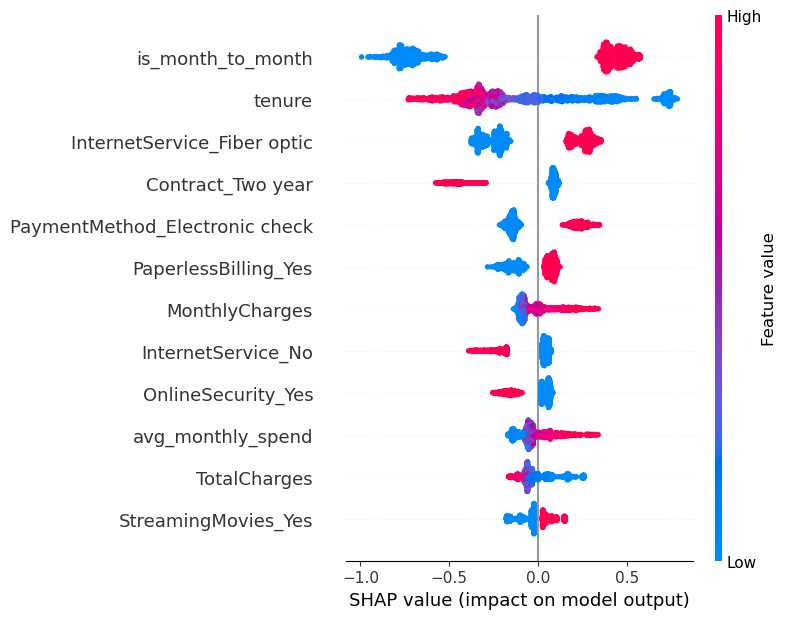

Example customer reasons:
avg_monthly_spend              0.201
InternetService_Fiber optic    0.172
MonthlyCharges                 0.160
dtype: float32


In [4]:
import shap

explainer = shap.TreeExplainer(churn_model)
shap_test = explainer.shap_values(X_test)

shap.summary_plot(shap_test, X_test, max_display=12, show=False)
plt.tight_layout(); plt.savefig("artifacts/shap_summary.png", dpi=150); plt.show()

def top_reasons(row_df, k=3):
    """Top features pushing a single customer's churn risk up."""
    vals = pd.Series(explainer.shap_values(row_df)[0], index=row_df.columns)
    return vals.sort_values(ascending=False).head(k).round(3)

print("Example customer reasons:")
print(top_reasons(X_test.iloc[[0]]))

## 4. Score every customer (out-of-fold, no leakage)

In [5]:
# Each customer is scored by a model that never saw them during training
df["churn_prob"] = cross_val_predict(churn_model, X, y, cv=5, method="predict_proba")[:, 1]
print("Out-of-fold AUC:", round(roc_auc_score(y, df["churn_prob"]), 3))

Out-of-fold AUC: 0.847


## 5. Survival regression — how long will each customer stay?

Tenure is *censored*: active customers haven't left yet, so plain regression on tenure is biased.
A Cox proportional hazards model handles this correctly and predicts expected remaining lifetime.

In [6]:
from lifelines import CoxPHFitter

leaky = ["tenure", "TotalCharges", "avg_monthly_spend", "charge_shock"]
surv = X.drop(columns=leaky)
surv = surv.loc[:, ~surv.T.duplicated()]             # drop perfectly duplicated dummy columns
surv["duration"] = df["tenure"].clip(lower=1)
surv["event"] = y

cph = CoxPHFitter(penalizer=0.1).fit(surv, duration_col="duration", event_col="event")
print("Survival model concordance:", round(cph.concordance_index_, 3))

active = df["Churn"] == 0
feats = surv.drop(columns=["duration", "event"])
remaining = cph.predict_expectation(feats[active], conditional_after=surv.loc[active, "duration"])
df["expected_remaining_months"] = 0.0
df.loc[active, "expected_remaining_months"] = np.asarray(remaining).ravel()

# Revenue at risk over the next 12 months
df["revenue_at_risk_12m"] = df["churn_prob"] * df["MonthlyCharges"] * np.minimum(df["expected_remaining_months"], 12)
top = df[active].sort_values("revenue_at_risk_12m", ascending=False)
print(f"Total 12-month revenue at risk (active customers): ${df.loc[active, 'revenue_at_risk_12m'].sum():,.0f}")
top[["customerID", "Contract", "MonthlyCharges", "churn_prob", "expected_remaining_months", "revenue_at_risk_12m"]].head(10).round(2)

Survival model concordance: 0.862
Total 12-month revenue at risk (active customers): $834,594


,customerID,Contract,MonthlyCharges,churn_prob,expected_remaining_months,revenue_at_risk_12m
1719,2081-VEYEH,Month-to-month,107.95,0.74,39.10,959.58
2238,1393-IMKZG,Month-to-month,95.85,0.80,23.56,922.39
5307,1941-HOSAM,Month-to-month,90.10,0.83,28.42,897.55
1568,3292-PBZEJ,Month-to-month,111.40,0.67,42.62,897.34
5354,4273-MBHYA,Month-to-month,89.35,0.83,19.96,891.42
2387,6734-GMPVK,Month-to-month,105.30,0.69,41.88,874.40
5140,7577-SWIFR,Month-to-month,89.25,0.82,18.21,874.34
2582,7145-FEJWU,Month-to-month,105.30,0.69,38.09,866.49
3159,5150-ITWWB,Month-to-month,94.85,0.75,24.90,854.63
2530,0722-SVSFK,Month-to-month,100.40,0.70,29.27,843.04


## 6. Customer segmentation (K-means + silhouette)

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_cols = ["tenure", "MonthlyCharges", "num_services", "is_month_to_month", "SeniorCitizen"]
seg_scaler = StandardScaler().fit(df[seg_cols])
Z = seg_scaler.transform(df[seg_cols])

scores = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z)) for k in range(2, 9)}
best_k = max(scores, key=scores.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in scores.items()}, "-> best k =", best_k)

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Z)
df["segment"] = kmeans.labels_
df.groupby("segment").agg(
    customers=("customerID", "count"),
    tenure=("tenure", "mean"),
    monthly=("MonthlyCharges", "mean"),
    services=("num_services", "mean"),
    month_to_month=("is_month_to_month", "mean"),
    churn_rate=("Churn", "mean"),
).round(2)

Silhouette by k: {2: 0.316, 3: 0.348, 4: 0.428, 5: 0.412, 6: 0.431, 7: 0.417, 8: 0.402} -> best k = 6


,customers,tenure,monthly,services,month_to_month,churn_rate
segment,,,,,,
0,392,58.45,93.60,6.58,0.27,0.18
1,1344,9.21,37.83,1.97,1.00,0.33
2,1614,56.39,86.47,6.68,0.01,0.09
3,707,18.26,75.64,3.96,0.99,0.57
4,1714,21.81,82.49,4.75,0.99,0.45
5,1272,40.40,26.84,1.77,0.00,0.03


## 7. Billing anomaly detection (Isolation Forest)

In [8]:
from sklearn.ensemble import IsolationForest

anom_cols = ["MonthlyCharges", "avg_monthly_spend", "charge_shock", "num_services", "tenure"]
iso = IsolationForest(contamination=0.03, random_state=42).fit(df[anom_cols])
df["billing_anomaly"] = (iso.predict(df[anom_cols]) == -1).astype(int)

print("Flagged customers:", df["billing_anomaly"].sum())
print(df.groupby("billing_anomaly")["Churn"].mean().rename({0: "normal churn rate", 1: "anomaly churn rate"}).round(3))

Flagged customers: 212
billing_anomaly
normal churn rate     0.265
anomaly churn rate    0.283
Name: Churn, dtype: float64


## 8. Add-on recommender — which service most reduces each customer's risk?

A model-based "what-if": for each add-on the customer doesn't have, flip it on and re-score.
This is associational, not causal — validate with an A/B test before acting on it.

In [9]:
def recommend_addon(i):
    row = X.loc[[i]]
    base = churn_model.predict_proba(row)[0, 1]
    if df.loc[i, "InternetService"] == "No":
        return None, 0.0
    best, best_drop = None, 0.0
    for a in ADDONS:
        if df.loc[i, a] == "No":
            trial = row.copy()
            trial[f"{a}_Yes"] = 1.0
            trial["num_services"] += 1
            drop = base - churn_model.predict_proba(trial)[0, 1]
            if drop > best_drop:
                best, best_drop = a, drop
    return best, best_drop

recs = [recommend_addon(i) for i in df.index]
df["recommended_addon"] = [r[0] for r in recs]
df["addon_risk_reduction"] = [round(r[1], 4) for r in recs]

print(df.loc[active, "recommended_addon"].value_counts())
df.loc[active].sort_values("revenue_at_risk_12m", ascending=False)[
    ["customerID", "churn_prob", "recommended_addon", "addon_risk_reduction"]].head(10).round(3)

recommended_addon
OnlineSecurity      1952
TechSupport          755
OnlineBackup         301
DeviceProtection      64
StreamingMovies       15
StreamingTV            1
Name: count, dtype: int64


,customerID,churn_prob,recommended_addon,addon_risk_reduction
1719,2081-VEYEH,0.741,OnlineSecurity,0.037
2238,1393-IMKZG,0.802,OnlineSecurity,0.030
5307,1941-HOSAM,0.830,OnlineSecurity,0.080
1568,3292-PBZEJ,0.671,OnlineSecurity,0.026
5354,4273-MBHYA,0.831,OnlineSecurity,0.080
2387,6734-GMPVK,0.692,OnlineSecurity,0.051
5140,7577-SWIFR,0.816,OnlineSecurity,0.079
2582,7145-FEJWU,0.686,TechSupport,0.052
3159,5150-ITWWB,0.751,OnlineSecurity,0.054
2530,0722-SVSFK,0.700,OnlineSecurity,0.024


## 9. Save everything for the next blocks (API, agent, dashboard)

In [10]:
joblib.dump({"model": churn_model, "columns": list(X.columns)}, "artifacts/churn_model.joblib")
joblib.dump(cph, "artifacts/survival_model.joblib")
joblib.dump({"kmeans": kmeans, "scaler": seg_scaler, "cols": seg_cols}, "artifacts/segments.joblib")
joblib.dump({"model": iso, "cols": anom_cols}, "artifacts/anomaly.joblib")
df.to_csv("artifacts/customers_scored.csv", index=False)

summary = {
    "logreg_auc": round(auc_lr, 3), "xgb_auc": round(auc_xgb, 3),
    "survival_concordance": round(cph.concordance_index_, 3), "segments": int(best_k),
    "revenue_at_risk_12m": round(float(df.loc[active, "revenue_at_risk_12m"].sum()), 0),
}
print(summary)

{'logreg_auc': 0.842, 'xgb_auc': 0.845, 'survival_concordance': np.float64(0.862), 'segments': 6, 'revenue_at_risk_12m': 834594.0}
